# PHẦN 1: KHỞI TẠO VÀ XỬ LÝ DỮ LIỆU


In [1]:
import numpy as np
import pandas as pd

# Thiết lập seed để kết quả ngẫu nhiên có thể tái lập được
np.random.seed(42)

# 1. Tạo MaKH từ 'KH001' đến 'KH500'
ma_kh = [f'KH{i:03d}' for i in range(1, 501)]

# 2. Tuoi: Ngẫu nhiên từ 18 đến 70. Chèn cố tình 10 giá trị NaN
tuoi = np.random.randint(18, 71, size=500).astype(float)
nan_indices_tuoi = np.random.choice(500, 10, replace=False)
tuoi[nan_indices_tuoi] = np.nan

# 3. ThuNhap: Ngẫu nhiên từ 5 triệu đến 50 triệu. Tạo thêm 5 outliers lên tới 200 triệu
thu_nhap = np.random.uniform(5_000_000, 50_000_000, size=500)
outlier_indices = np.random.choice(500, 5, replace=False)
thu_nhap[outlier_indices] = 200_000_000

# 4. GioiTinh: Chọn ngẫu nhiên ['Nam', 'Nữ']. Chèn cố tình 15 giá trị NaN
gioi_tinh = np.random.choice(['Nam', 'Nữ'], size=500).astype(object)
nan_indices_gioi = np.random.choice(500, 15, replace=False)
gioi_tinh[nan_indices_gioi] = np.nan

# 5. ThanhPho: Chọn ngẫu nhiên ['Hà Nội', 'Đà Nẵng', 'TP.HCM']
thanh_pho = np.random.choice(['Hà Nội', 'Đà Nẵng', 'TP.HCM'], size=500)

# 6. TongChiTieu: Số thực, tương quan nhẹ với ThuNhap
tong_chi_tieu = 0.3 * thu_nhap + np.random.normal(5_000_000, 3_000_000, size=500)
tong_chi_tieu = np.clip(tong_chi_tieu, a_min=1_000_000, a_max=None) # Đảm bảo không âm

# Tạo DataFrame gốc
df_khachhang = pd.DataFrame({
    'MaKH': ma_kh,
    'Tuoi': tuoi,
    'ThuNhap': thu_nhap,
    'GioiTinh': gioi_tinh,
    'ThanhPho': thanh_pho,
    'TongChiTieu': tong_chi_tieu
})

# Hiển thị 5 dòng đầu
df_khachhang.head()

,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu
0,KH001,56.0,1.986568e+07,Nữ,Đà Nẵng,6.340705e+06
1,KH002,69.0,4.701613e+07,Nam,Đà Nẵng,1.464601e+07
2,KH003,46.0,5.339046e+06,Nữ,Đà Nẵng,8.188588e+06
3,KH004,32.0,1.513998e+07,Nữ,Đà Nẵng,3.425109e+06
4,KH005,60.0,2.144106e+07,Nữ,Đà Nẵng,1.198222e+07


In [2]:
# Kiểm tra số lượng giá trị khuyết trên mỗi cột
print("Số lượng giá trị khuyết trước khi xử lý:")
print(df_khachhang.isnull().sum())
print("-" * 40)

# Điền khuyết cột Tuoi bằng giá trị Trung vị (Median)
median_tuoi = df_khachhang['Tuoi'].median()
df_khachhang['Tuoi'] = df_khachhang['Tuoi'].fillna(median_tuoi)

# Điền khuyết cột GioiTinh bằng giá trị xuất hiện nhiều nhất (Mode)
mode_gioitinh = df_khachhang['GioiTinh'].mode()[0]
df_khachhang['GioiTinh'] = df_khachhang['GioiTinh'].fillna(mode_gioitinh)

# Kiểm tra lại sau khi điền khuyết
print("Số lượng giá trị khuyết sau khi xử lý:")
print(df_khachhang.isnull().sum())

Số lượng giá trị khuyết trước khi xử lý:
MaKH            0
Tuoi           10
ThuNhap         0
GioiTinh       15
ThanhPho        0
TongChiTieu     0
dtype: int64
----------------------------------------
Số lượng giá trị khuyết sau khi xử lý:
MaKH           0
Tuoi           0
ThuNhap        0
GioiTinh       0
ThanhPho       0
TongChiTieu    0
dtype: int64


In [3]:
# Áp dụng One-Hot Encoding (pd.get_dummies) cho cột ThanhPho và gộp vào DataFrame gốc
df_khachhang = pd.get_dummies(df_khachhang, columns=['ThanhPho'], prefix='ThanhPho', dtype=int)

df_khachhang.head()

,MaKH,Tuoi,ThuNhap,GioiTinh,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng
0,KH001,56.0,1.986568e+07,Nữ,6.340705e+06,0,0,1
1,KH002,69.0,4.701613e+07,Nam,1.464601e+07,0,0,1
2,KH003,46.0,5.339046e+06,Nữ,8.188588e+06,0,0,1
3,KH004,32.0,1.513998e+07,Nữ,3.425109e+06,0,0,1
4,KH005,60.0,2.144106e+07,Nữ,1.198222e+07,0,0,1


In [4]:
# Tính Q1, Q3 cho cột ThuNhap
Q1 = df_khachhang['ThuNhap'].quantile(0.25)
Q3 = df_khachhang['ThuNhap'].quantile(0.75)
IQR = Q3 - Q1

# Xác định giới hạn trên và dưới
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Giới hạn dưới: {lower_bound:,.0f} | Giới hạn trên: {upper_bound:,.0f}")

# Lọc bỏ (xóa các dòng) có giá trị ThuNhap là Outlier
df_khachhang = df_khachhang[(df_khachhang['ThuNhap'] >= lower_bound) & (df_khachhang['ThuNhap'] <= upper_bound)].copy()

print(f"Số lượng dòng sau khi lọc bỏ Outliers: {len(df_khachhang)}")

Giới hạn dưới: -15,826,436 | Giới hạn trên: 73,011,542
Số lượng dòng sau khi lọc bỏ Outliers: 495


In [5]:
from sklearn.preprocessing import MinMaxScaler

# Sử dụng MinMaxScaler để chuẩn hóa cột TongChiTieu về dải [0, 1]
scaler = MinMaxScaler()
df_khachhang['TongChiTieu_Scaled'] = scaler.fit_transform(df_khachhang[['TongChiTieu']])

df_khachhang[['TongChiTieu', 'TongChiTieu_Scaled']].head()

,TongChiTieu,TongChiTieu_Scaled
0,6.340705e+06,0.202368
1,1.464601e+07,0.517071
2,8.188588e+06,0.272388
3,3.425109e+06,0.091892
4,1.198222e+07,0.416135


In [6]:
# Trích xuất khách hàng là 'Nữ', Tuoi > 30, và đang ở 'Hà Nội' (ThanhPho_Hà Nội == 1)
df_phu = df_khachhang[
    (df_khachhang['GioiTinh'] == 'Nữ') & 
    (df_khachhang['Tuoi'] > 30) & 
    (df_khachhang['ThanhPho_Hà Nội'] == 1)
]

# In ra 5 dòng đầu tiên
df_phu.head(5)

,MaKH,Tuoi,ThuNhap,GioiTinh,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng,TongChiTieu_Scaled
13,KH014,70.0,3.636327e+07,Nữ,1.331386e+07,1,0,0,0.466593
16,KH017,41.0,3.091993e+07,Nữ,1.716024e+07,1,0,0,0.612339
32,KH033,66.0,2.884280e+07,Nữ,1.445050e+07,1,0,0,0.509662
35,KH036,45.0,8.928058e+06,Nữ,8.518782e+06,1,0,0,0.284899
43,KH044,54.0,2.970149e+07,Nữ,1.704814e+07,1,0,0,0.608091


In [7]:
# Định nghĩa hàm đảo ngược từ One-Hot về nhãn chuỗi để groupby trực quan
def get_city_name(row):
    if row['ThanhPho_Hà Nội'] == 1: return 'Hà Nội'
    elif row['ThanhPho_Đà Nẵng'] == 1: return 'Đà Nẵng'
    else: return 'TP.HCM'

df_khachhang['ThanhPho_Nhan'] = df_khachhang.apply(get_city_name, axis=1)

# Sử dụng hàm groupby() để tính Trung bình (Mean) và Tổng (Sum) của TongChiTieu
thong_ke = df_khachhang.groupby('ThanhPho_Nhan')['TongChiTieu'].agg(['mean', 'sum'])
print(thong_ke)

# Xóa cột nhãn tạm thời để không ảnh hưởng dữ liệu gốc
df_khachhang = df_khachhang.drop(columns=['ThanhPho_Nhan'])

                       mean           sum
ThanhPho_Nhan                            
Hà Nội         1.349010e+07  2.347278e+09
TP.HCM         1.343398e+07  2.230041e+09
Đà Nẵng        1.317987e+07  2.042880e+09


In [8]:
# Tạo cột NhomTuoi bằng hàm pd.cut()
bins = [18, 30, 45, 60, np.inf]
labels = ['18-30', '31-45', '46-60', 'Trên 60']

df_khachhang['NhomTuoi'] = pd.cut(df_khachhang['Tuoi'], bins=bins, labels=labels, include_lowest=True)

df_khachhang[['Tuoi', 'NhomTuoi']].head()

,Tuoi,NhomTuoi
0,56.0,46-60
1,69.0,Trên 60
2,46.0,46-60
3,32.0,31-45
4,60.0,46-60


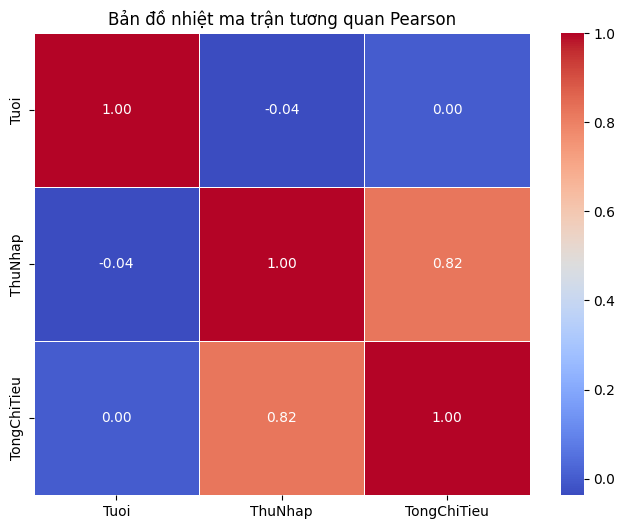

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính ma trận tương quan Pearson giữa các biến số
matrix = df_khachhang[['Tuoi', 'ThuNhap', 'TongChiTieu']].corr(method='pearson')

# Vẽ bản đồ nhiệt (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Bản đồ nhiệt ma trận tương quan Pearson')
plt.show()

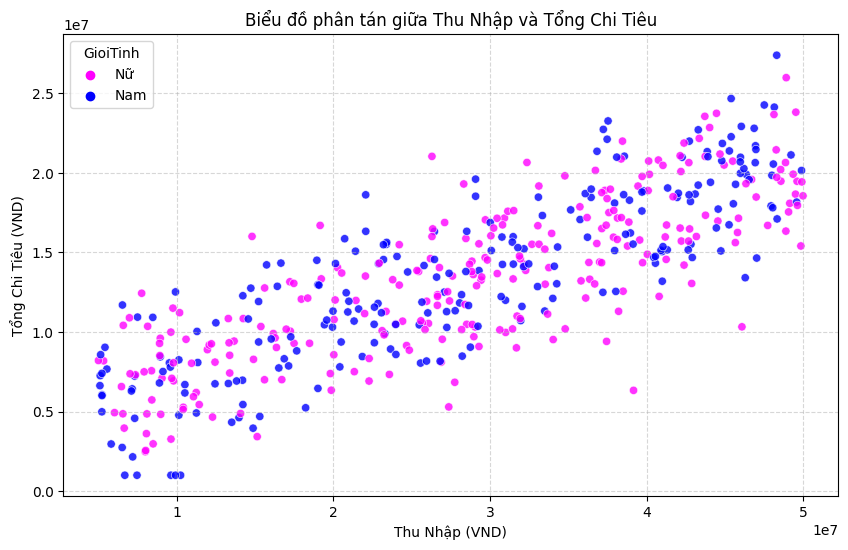

In [10]:
# Vẽ biểu đồ Scatter Plot thể hiện quan hệ ThuNhap (X) và TongChiTieu (Y)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_khachhang, 
    x='ThuNhap', 
    y='TongChiTieu', 
    hue='GioiTinh', 
    palette={'Nam': 'blue', 'Nữ': 'magenta'},
    alpha=0.8
)

plt.title('Biểu đồ phân tán giữa Thu Nhập và Tổng Chi Tiêu')
plt.xlabel('Thu Nhập (VND)')
plt.ylabel('Tổng Chi Tiêu (VND)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# PHẦN 2: ỨNG DỤNG HỌC SÂU - MẠNG NƠ-RON TÍCH CHẬP


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Tiền xử lý dữ liệu
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Chuẩn hóa giá trị pixel về khoảng [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape dữ liệu cho phù hợp với đầu vào của CNN (thêm kênh màu đơn)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 2. Xây dựng kiến trúc CNN (Mô hình Sequential)
model = models.Sequential([
    # 1 lớp Tích chập (Conv2D) với 32 filters, kernel 3x3, activation ReLU
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    
    # 1 lớp Pooling (MaxPooling2D)
    layers.MaxPooling2D((2, 2)),
    
    # 1 lớp Flatten để duỗi dữ liệu
    layers.Flatten(),
    
    # 1 lớp ẩn (Dense) 64 units, activation ReLU
    layers.Dense(64, activation='relu'),
    
    # Lớp đầu ra (Dense) với 10 units, activation Softmax
    layers.Dense(10, activation='softmax')
])

# 3. Biên dịch và Huấn luyện
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fit mô hình trên tập train trong 5 epochs
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

# 4. Đánh giá độ chính xác trên tập kiểm thử
print("\n--- ĐÁNH GIÁ MÔ HÌNH ---")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\nĐộ chính xác (Accuracy) trên tập kiểm thử: {test_acc * 100:.2f}%")


4422102/4422102 [==============================] - 0s 0us/step
Epoch 1/5
938/938 [==============================] - 34s 35ms/step - loss: 0.4337 - accuracy: 0.8496 - val_loss: 0.3588 - val_accuracy: 0.8682
Epoch 2/5
938/938 [==============================] - 31s 34ms/step - loss: 0.2986 - accuracy: 0.8947 - val_loss: 0.3007 - val_accuracy: 0.8926
Epoch 3/5
938/938 [==============================] - 32s 34ms/step - loss: 0.2582 - accuracy: 0.9069 - val_loss: 0.2767 - val_accuracy: 0.8973
Epoch 4/5
938/938 [==============================] - 33s 35ms/step - loss: 0.2295 - accuracy: 0.9170 - val_loss: 0.2777 - val_accuracy: 0.8999
Epoch 5/5
938/938 [==============================] - 31s 34ms/step - loss: 0.2065 - accuracy: 0.9245 - val_loss: 0.2823 - val_accuracy: 0.8986

--- ĐÁNH GIÁ MÔ HÌNH ---
313/313 [==============================] - 2s 5ms/step - loss: 0.2823 - accuracy: 0.8986

Độ chính xác (Accuracy) trên tập kiểm thử: 89.86%
